🧩 Employees showing career stagnation risk: 15


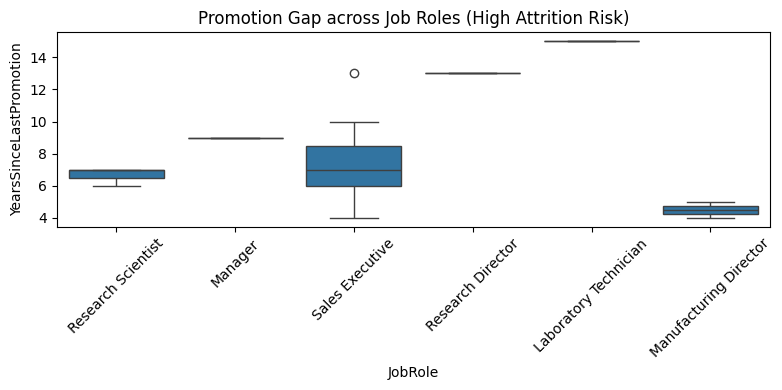

💼 Employees working overtime but earning below-median income: 202


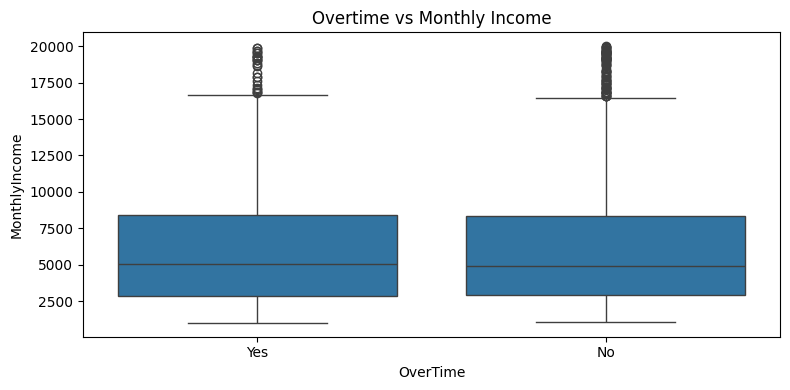

🚗 Employees with long commutes at attrition risk: 58


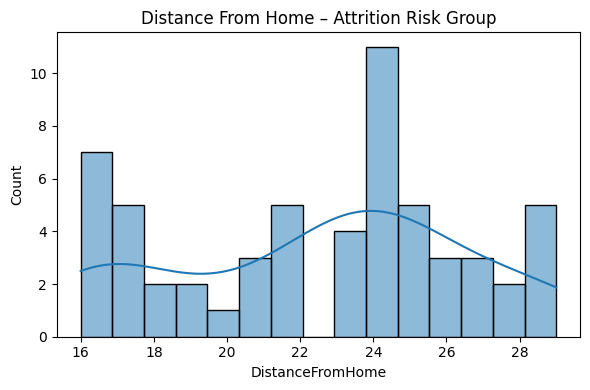


📋 Final Business Recommendations:
- 🎯 Introduce career development programs for employees with >3 years since last promotion.
- 💸 Review overtime policies and salary bands for underpaid high-load employees.
- 🏠 Offer hybrid/remote options for employees with long commutes.


In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import sklearn

# 1️⃣ Load dataset 
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\HR-Employee-Attrition.csv")

df.columns = df.columns.str.strip()

# 2️⃣ Prepare target
target = "Attrition"
df['AttritionFlag'] = df[target].map({"Yes": 1, "No": 0})

X = df.drop(columns=[target, 'AttritionFlag'])
y = df['AttritionFlag']

# 3️⃣ Column types 
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

# 4️⃣ Version-safe OneHotEncoder
if int(sklearn.__version__.split('.')[1]) >= 2:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

# 5️⃣ Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', ohe, cat_cols)
])

# 6️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7️⃣ Use Pipeline
model = Pipeline([
    ('pre', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

# 8️⃣ Predictions for insights
df['PredictedAttrition'] = model.predict(X)

# =============================
# 📊 INSIGHT 1 – Career stagnation
# =============================
stagnant = df[
    (df['YearsSinceLastPromotion'] > 3) &
    (df['JobSatisfaction'] <= 2) &
    (df['PredictedAttrition'] == 1)
]

print(f"🧩 Employees showing career stagnation risk: {len(stagnant)}")

plt.figure(figsize=(8, 4))
sns.boxplot(data=stagnant, x='JobRole', y='YearsSinceLastPromotion')
plt.title("Promotion Gap across Job Roles (High Attrition Risk)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================
# 💰 INSIGHT 2 – Overtime vs Pay
# =============================
overtime_risk = df[
    (df['OverTime'] == 'Yes') &
    (df['MonthlyIncome'] < df['MonthlyIncome'].median())
]

print(f"💼 Employees working overtime but earning below-median income: {len(overtime_risk)}")

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='OverTime', y='MonthlyIncome')
plt.title("Overtime vs Monthly Income")
plt.tight_layout()
plt.show()

# =============================
# 🏠 INSIGHT 3 – Commute Risk
# =============================
commute_risk = df[
    (df['DistanceFromHome'] > 15) &
    (df['PredictedAttrition'] == 1)
]

print(f"🚗 Employees with long commutes at attrition risk: {len(commute_risk)}")

plt.figure(figsize=(6, 4))
sns.histplot(commute_risk['DistanceFromHome'], bins=15, kde=True)
plt.title("Distance From Home – Attrition Risk Group")
plt.tight_layout()
plt.show()

# =============================
# 🧠 BUSINESS RECOMMENDATIONS
# =============================
print("\n📋 Final Business Recommendations:")

suggestions = [
    "🎯 Introduce career development programs for employees with >3 years since last promotion.",
    "💸 Review overtime policies and salary bands for underpaid high-load employees.",
    "🏠 Offer hybrid/remote options for employees with long commutes."
]

for s in suggestions:
    print("-", s)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Attrition distribution')

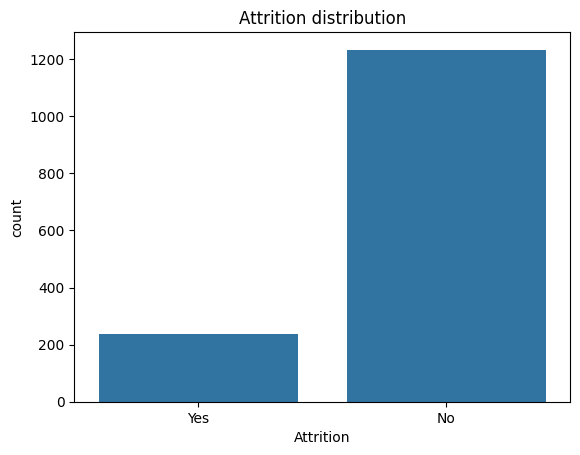

In [51]:
print(df['Attrition'].value_counts(normalize=True))
sns.countplot(x='Attrition', data=df);
plt.title('Attrition distribution')

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Numerical: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAt

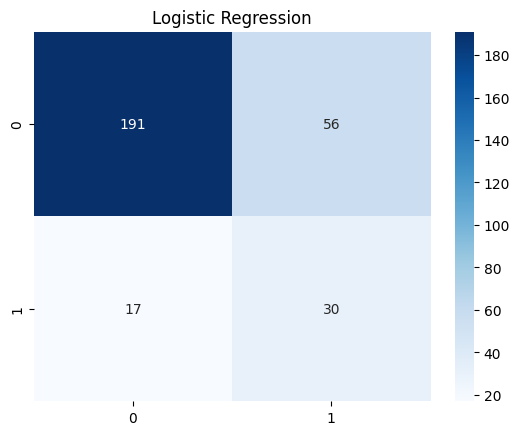


========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294

ROC AUC: 0.7831854595572402


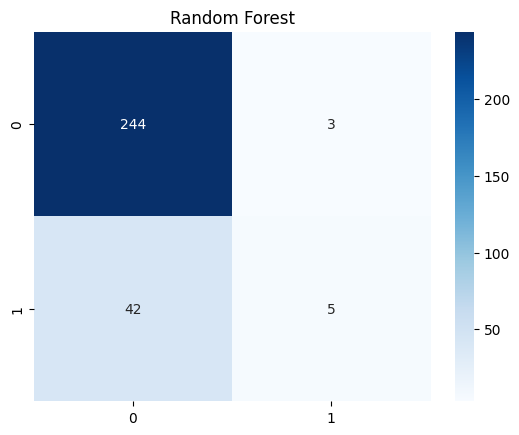

C:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Running SHAP...


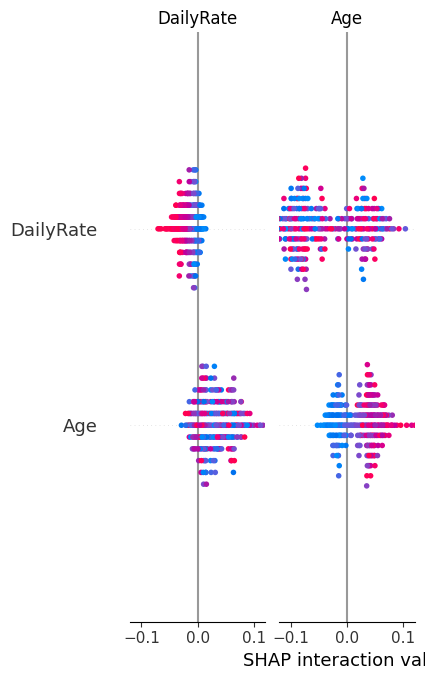

In [48]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\HR-Employee-Attrition.csv")
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())

# =========================
# 3. TARGET CREATION
# =========================
df['AttritionFlag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Drop unnecessary columns
cols_to_drop = ['EmployeeCount','EmployeeNumber','Over18','StandardHours','Attrition']
df = df.drop([c for c in cols_to_drop if c in df.columns], axis=1)

# =========================
# 4. COLUMN TYPES
# =========================
# Fix pandas warning
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
if 'AttritionFlag' in num_cols:
    num_cols.remove('AttritionFlag')

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X = df.drop('AttritionFlag', axis=1)
y = df['AttritionFlag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 6. PREPROCESSING
# =========================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import sklearn

# Version-safe OneHotEncoder
if int(sklearn.__version__.split('.')[1]) >= 2:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', ohe)
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# =========================
# 7. MODELS
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe_lr = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

# =========================
# 8. EVALUATION
# =========================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for name, model in [('Logistic Regression', pipe_lr), ('Random Forest', pipe_rf)]:
    print(f"\n========== {name} ==========")

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, preds))
    print("ROC AUC:", roc_auc_score(y_test, probs))

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.show()

# =========================
# 9. SHAP INTERPRETATION
# =========================
import shap

print("\nRunning SHAP...")

# Fit preprocessor
preprocessor.fit(X_train)

X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# Feature names
ohe_model = preprocessor.named_transformers_['cat'].named_steps['ohe']
cat_names = ohe_model.get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(cat_names)

# Train RF separately for SHAP
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_trans, y_train)

# SHAP
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_trans)

# Handle binary output
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# Plot
shap.summary_plot(shap_vals, X_test_trans, feature_names=feature_names)